In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data

In [3]:
df_restaurants = pd.read_csv(
    r"C:\Users\TNath\OneDrive\School\2025-2026\Spring\Recommender Systems\Recommender Systems Code\Final Project\team_project_dataset\restaurants_santa_barbara.csv")
df_restaurants.head()

,business_id,name,address,city,state,postal_code,categories,latitude,longitude,attributes
0,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,"131 Anacapa St, Ste C",Santa Barbara,CA,93101,"food, restaurants, salad, coffee & tea, breakf...",34.414445,-119.690672,"{'RestaurantsTakeOut': 'True', 'NoiseLevel': ""..."
1,SZU9c8V2GuREDN5KgyHFJw,Santa Barbara Shellfish Company,230 Stearns Wharf,Santa Barbara,CA,93101,"live/raw food, restaurants, seafood, beer bar,...",34.408715,-119.685019,"{'OutdoorSeating': 'True', 'RestaurantsAttire'..."
2,ifjluUv4VASwmFqEp8cWlQ,Marty's Pizza,2733 De La Vina St,Santa Barbara,CA,93105,"pizza, restaurants",34.436236,-119.726147,"{'Alcohol': ""u'none'"", 'BusinessAcceptsCreditC..."
3,UFpCraqzFBAhtZqmxmiWsA,Cat Therapy,"1213 State St, Ste L",Santa Barbara,CA,93101,"themed cafes, cafes, pets, arts & entertainmen...",34.423302,-119.705471,"{'WheelchairAccessible': 'True', 'WiFi': ""u'fr..."
4,Hqz96v1ymucUKNzIWfEKXw,Subway,"1936 State St, Ste B",Santa Barbara,CA,93101,"restaurants, delis, sandwiches, fast food",34.430822,-119.714156,"{'Alcohol': ""u'none'"", 'Caters': 'True', 'Bike..."


In [4]:
df_test_reviews = pd.read_csv(
    r"C:\Users\TNath\OneDrive\School\2025-2026\Spring\Recommender Systems\Recommender Systems Code\Final Project\team_project_dataset\test_reviews_santa_barbara.csv"
)
df_test_reviews.head()

,review_id,user_id,business_id,stars,datetime,text
0,FtyShIUZr_D_SH-v62mgWQ,-0EcgtUXe1rzrkmdih_tYg,hPzPpfSjgQkpWCD7YjcY-A,4.0,2018-08-08 19:40:08,"We had the Lorraine quiche, super good. The pa..."
1,pwOykiCXDD5u0K5SnVPhyQ,-1-ECBsGpG4Iw5s-ecnfqw,29YqJwOGEuAWqlHZxMc1OA,5.0,2020-02-03 19:52:29,The bar at Paradise Cafe has always been one o...
2,2biRxTQm5gwWXIYTtSfeXA,-14MA777BbjUQLw0zndvfA,Ce6B2-CYAjGvRZe3GKyxYA,2.0,2021-09-24 23:46:39,Amazing pizza but the people who answer the ph...
3,45lQuUIWCwo2-xXioCLItg,-1WbN1Qd-opw8u3uEqs2Kg,mAqgsZBTN-wsShMpkz2o9g,1.0,2017-11-04 21:35:28,Super sad where this once great place has ende...
4,Y-0xRadP9tQYB8Sg8-MFjw,-2hJrZCnH3vvUIET84kVJw,0qu0fNTOsSmuREYVIMPuIQ,5.0,2010-06-24 22:01:16,"One of the best places, right around the corne..."


In [5]:
df_train_reviews = pd.read_csv(
    r"C:\Users\TNath\OneDrive\School\2025-2026\Spring\Recommender Systems\Recommender Systems Code\Final Project\team_project_dataset\train_reviews_santa_barbara.csv"
)
df_train_reviews.head()

,review_id,user_id,business_id,stars,datetime,text
0,ixa--i8zAivs8rD10tleZQ,-0EcgtUXe1rzrkmdih_tYg,VgAKmXE8B7J0I_O_R13UKQ,4.0,2018-07-03 03:24:32,I lived here before and not once that I came t...
1,MHj1HEPM5Bv7_UhoiwOSGA,-0EcgtUXe1rzrkmdih_tYg,YrNtBUOUOYwmRZ_UVwH8iQ,4.0,2018-07-04 15:47:17,Totally a great experienced. Been coming to S...
2,_sTp9AsEu60ORSqqb9juJg,-0EcgtUXe1rzrkmdih_tYg,Aes-0Q_guDeYewMapFs_vg,4.0,2018-07-06 05:38:42,"Great outdoor seating, the servers are attenti..."
3,2Tcu86xzIADtfuy5jeio9A,-0EcgtUXe1rzrkmdih_tYg,9ugpNKKhnYRa51qXoxUw_A,3.0,2018-07-06 05:49:49,Went for the first time. The lady in the fron...
4,J6X5I_LQnii7QeIW79gBVg,-0EcgtUXe1rzrkmdih_tYg,DOfiulOub9hVPBCtiDl9Fw,3.0,2018-07-06 06:05:15,"Pizza was great, servers are friendly and atte..."


### Total Restaurants, Total Reviews, Reviews Per User

In [6]:
total_restaurants = df_restaurants.shape[0]
print(f"Total restaurants: {total_restaurants}")

Total restaurants: 767


In [7]:
df_total_reviews = pd.concat([df_restaurants, df_train_reviews],ignore_index=True)
total_reviews = len(df_total_reviews)
print(f"Total reviews: {total_reviews}")
total_ratings = df_total_reviews['stars'].notna().sum()
print(f"Total ratings: {total_ratings}")

Total reviews: 42348
Total ratings: 41581


In [8]:
reviews_per_user = (
    df_total_reviews
    .groupby('user_id')
    .size()
    .reset_index(name="review_count")
    .sort_values('review_count', ascending=False)
)
print(reviews_per_user.head())

                     user_id  review_count
2733  ZDCWEctaQHfJQT1sH_rMmA           152
3897  o6UJMpHcpLJEvmKLrxLS3w           152
852   A4bsa7ykYRVCnb4h2vZALw           146
12    -B-QEUESGWHPE_889WJaeg           133
3445  iJQtNnEcrxdpaD132v26nQ           129


### Number of Reviews per Restaurant

In [9]:
reviews_per_restaurant = (
    df_total_reviews
    .groupby('business_id')
    .agg(
        review_count   = ('stars','count'),
        avg_rating     = ('stars','mean'),
        rating_std     = ('stars','std'),
        unique_reviews = ('user_id', 'nunique')
    )
    .reset_index()
    .sort_values('review_count',ascending=False)
    .merge(df_restaurants[['business_id','name']],on='business_id',how='left')
)
reviews_per_restaurant = reviews_per_restaurant.round(2)
print(reviews_per_restaurant.head())

              business_id  review_count  avg_rating  rating_std  \
0  yPSejq3_erxo9zdVYTBnZA           670        4.40        0.91   
1  U3grYFIeu6RgAAQgdriHww           561        4.14        0.96   
2  skY6r8WAkYqpV7_TxNm23w           523        4.04        1.03   
3  6RBZfirnzE4NahJTn1UPNA           369        3.84        1.14   
4  3Wy21heeDm8h2tSZfcj6OA           361        4.28        0.92   

   unique_reviews                         name  
0             670                   Los Agaves  
1             561  Brophy Bros - Santa Barbara  
2             523  Boathouse at Hendry's Beach  
3             369       La Super-Rica Taqueria  
4             361              Lure Fish House  


In [10]:
#Total Overview of Reviews, Ratings, Standard Deviations, and Unique Reviews for all restaurants
print(reviews_per_restaurant[['review_count','avg_rating','rating_std','unique_reviews']].describe())

       review_count  avg_rating  rating_std  unique_reviews
count    781.000000  694.000000  689.000000      781.000000
mean      53.240717    3.887104    1.099739       53.240717
std       70.684154    0.587597    0.331319       70.684154
min        0.000000    1.470000    0.000000        0.000000
25%        9.000000    3.590000    0.960000        9.000000
50%       28.000000    3.960000    1.130000       28.000000
75%       73.000000    4.290000    1.290000       73.000000
max      670.000000    5.000000    2.310000      670.000000


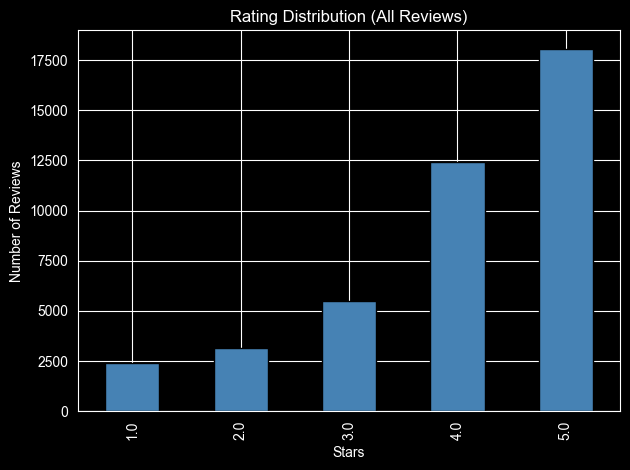

In [12]:
#Rating Distribution
rating_counts = df_total_reviews['stars'].value_counts().sort_index()
rating_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution (All Reviews)')
plt.xlabel('Stars')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

### Number of restaurants across different categories

In [15]:
category_counts = (
    df_restaurants['categories']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)
category_counts.columns=['category','count']
category_counts = category_counts.iloc[2:]


print(category_counts.head())

             category  count
2           nightlife    173
3                bars    158
4      american (new)    151
5  breakfast & brunch    119
6             mexican    118


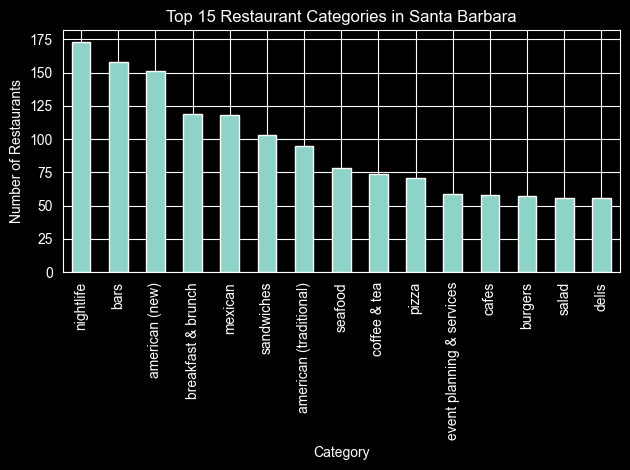

In [16]:
category_counts.head(15).plot(
    kind='bar', x='category', y='count', legend=False
)
plt.title('Top 15 Restaurant Categories in Santa Barbara')
plt.xlabel('Category')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

In [27]:
print(f"Total unique categories: {len(category_counts)}")
print(f"Top 15 categories \n----------------------------------")
for i, cat in enumerate(category_counts.head(15)['category'], start=1):
    print(f"{i}. {cat}")

Total unique categories: 222
Top 15 categories 
----------------------------------
1. nightlife
2. bars
3. american (new)
4. breakfast & brunch
5. mexican
6. sandwiches
7. american (traditional)
8. seafood
9. coffee & tea
10. pizza
11. event planning & services
12. cafes
13. burgers
14. salad
15. delis


### Sparsity

In [14]:
total_users = df_total_reviews['user_id'].nunique()
total_restaurants_count = df_restaurants.shape[0]
sparsity = 1 - (len(df_total_reviews) / (total_users * total_restaurants_count))
print(f"Sparsity: {sparsity*100:.2f}%")


Sparsity: 98.85%


### Attribute Analysis

In [18]:
import ast
from collections import Counter

def parse_attributes(attr_str):
    try:
        return ast.literal_eval(attr_str)
    except:
        return {}

df_restaurants['parsed_attrs'] = df_restaurants['attributes'].apply(parse_attributes)

attr_counts = Counter(
    key for attrs in df_restaurants['parsed_attrs'] for key in attrs.keys()
)

attr_df = (pd.DataFrame(attr_counts.items(), columns=['attribute', 'count'])
             .sort_values('count', ascending=False)
             .reset_index(drop=True))

print(f"Total unique attributes: {len(attr_df)}")
print(attr_df.head(15).to_string(index=False))

Total unique attributes: 35
                 attribute  count
BusinessAcceptsCreditCards    726
            OutdoorSeating    703
        RestaurantsTakeOut    700
           BusinessParking    693
    RestaurantsPriceRange2    690
       RestaurantsDelivery    679
   RestaurantsReservations    658
                   Alcohol    643
  RestaurantsGoodForGroups    631
                     HasTV    622
                  Ambience    619
               GoodForKids    615
                      WiFi    601
         RestaurantsAttire    595
               BikeParking    574


222
